In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

# -----------------------------
# Load and basic cleaning
# -----------------------------
dfs = [pd.read_parquet(f"/content/drive/MyDrive/Hackaton3/01_cleaned_data_part_{i}.parquet") for i in range(1,50)]
df = pd.concat(dfs, ignore_index=True)

df = df.drop(columns=["issn", "isbn"], errors="ignore")
df = df.dropna(subset=["id", "references"]).copy()

# Keep references as clean, non-empty string lists
def clean_references(x):
    if isinstance(x, (list, np.ndarray)):
        out = [r for r in x if r is not None and str(r).strip() != ""]
        return out
    return []

df["references"] = df["references"].apply(clean_references)
df = df[df["references"].map(len) > 0].reset_index(drop=True)

# Helper function: check whether a value is empty
def is_not_empty(x):
    if isinstance(x, (list, np.ndarray)):
        return len(x) > 0
    elif pd.isna(x):
        return False
    else:
        return len(str(x).strip()) > 0

# Apply to all rows without using applymap
mask = df.apply(lambda row: all(is_not_empty(v) for v in row), axis=1)

# Keep only fully populated rows
df = df[mask].reset_index(drop=True)

print("Righe dopo rimozione valori vuoti:", len(df))

# -----------------------------
# Build positive pairs
# -----------------------------
pairs = df[["id", "references"]].explode("references")
pairs = pairs.rename(columns={"id": "article_id", "references": "ref_id"})
pairs = pairs.dropna(subset=["ref_id"])
pairs = pairs[pairs["ref_id"].astype(str).str.strip() != ""].reset_index(drop=True)

# Filter references that exist in the dataset
ref_ids_in_dataset = set(df["id"].values)
pairs = pairs[pairs["ref_id"].isin(ref_ids_in_dataset)].reset_index(drop=True)

# Article and reference feature tables
article_features = df.drop(columns=["references"]).add_suffix("_article")
article_features = article_features.rename(columns={"id_article": "article_id"})

ref_features = df.drop(columns=["references"]).add_suffix("_ref")
ref_features = ref_features.rename(columns={"id_ref": "ref_id"})

# Positive samples: (article_id, real ref_id)
df_pos = (
    pairs
    .merge(article_features, on="article_id", how="left")
    .merge(ref_features, on="ref_id", how="inner")
)
df_pos["is_reference_valid"] = 1

print("Positive samples:", len(df_pos))

# -----------------------------
# Build fake negative references
# -----------------------------
all_ids = df["id"].to_numpy()
true_refs_by_article = df.set_index("id")["references"].apply(set).to_dict()

fake_ref_ids = []
for article_id in pairs["article_id"].to_numpy():
    true_refs = true_refs_by_article.get(article_id, set())

    # Draw a random reference that is not a true reference for this article
    fake = np.random.choice(all_ids)
    while fake in true_refs:
        fake = np.random.choice(all_ids)
    fake_ref_ids.append(fake)

neg_pairs = pairs[["article_id"]].copy()
neg_pairs["ref_id"] = fake_ref_ids

# Negative samples: (article_id, fake ref_id)
df_neg = (
    neg_pairs
    .merge(article_features, on="article_id", how="left")
    .merge(ref_features, on="ref_id", how="inner")
)
df_neg["is_reference_valid"] = 0

print("Negative samples:", len(df_neg))

# -----------------------------
# Final training dataset
# -----------------------------
df_training = pd.concat([df_pos, df_neg], ignore_index=True)
df_training = df_training.dropna().sort_values("year_article").reset_index(drop=True)


df_training.dropna(inplace=True)
df_training.sort_values('year_article', inplace=True)

df_training = df_training[df_training["year_article"] >= df_training['year_ref']].reset_index(drop=True)

print("Final training dataset:", len(df_training))

Righe dopo rimozione valori vuoti: 965269
Positive samples: 4897416
Negative samples: 4897416
Final training dataset: 7866801


In [4]:
print("Training dataset size:", len(df_training))
print("\nis_reference_valid dtype:")
print(df_training["is_reference_valid"].dtype)
print("\nLabel distribution:")
print(df_training["is_reference_valid"].value_counts())
print("\nPositive sample preview:")
df_training.columns

Training dataset size: 7866801

is_reference_valid dtype:
int64

Label distribution:
is_reference_valid
1    4856179
0    3010622
Name: count, dtype: int64

Positive sample preview:


Index(['article_id', 'ref_id', 'title_article', 'abstract_article',
       'keywords_article', 'year_article', 'authors_article',
       'page_start_article', 'page_end_article', 'lang_article',
       'volume_article', 'issue_article', 'doi_article', 'url_article',
       'n_citation_article', 'venue_article', 'doc_type_article', 'title_ref',
       'abstract_ref', 'keywords_ref', 'year_ref', 'authors_ref',
       'page_start_ref', 'page_end_ref', 'lang_ref', 'volume_ref', 'issue_ref',
       'doi_ref', 'url_ref', 'n_citation_ref', 'venue_ref', 'doc_type_ref',
       'is_reference_valid'],
      dtype='object')

In [12]:
from transformers import BertForSequenceClassification, BertTokenizer, BertTokenizerFast

model_name = "bert-base-uncased"
try:
    tok = BertTokenizerFast.from_pretrained(model_name)
    mode = "BertTokenizerFast"
except Exception:
    tok = BertTokenizer.from_pretrained(model_name)
    mode = "BertTokenizer"

tokenizer = tok
mdl = BertForSequenceClassification.from_pretrained(model_name, num_labels=1)
print(f"Tokenizer loaded with {mode}; vocab size = {tok.vocab_size}")
print("Model loaded:", mdl.__class__.__name__)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenizer loaded with BertTokenizerFast; vocab size = 30522
Model loaded: BertForSequenceClassification


In [ ]:
import os
import pickle
import torch
from torch.utils.data import Dataset, random_split
from transformers import Trainer, TrainingArguments, TrainerCallback
from torch.backends import cudnn
import torch.nn as nn
import matplotlib.pyplot as plt

# ===============================
# --- GPU optimization ---
# ===============================
cudnn.benchmark = True

use_cuda = torch.cuda.is_available()
device = torch.device('cuda' if use_cuda else 'cpu')

if use_cuda:
    print(f"GPU attiva: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA non disponibile: uso CPU")

# ===============================
# --- Dataset ---
# ===============================
class CitationDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        article_text = f"{row['title_article']} {row.get('article_abstract','')} {row.get('article_keywords','')}"
        ref_text = f"{row['title_ref']} {row.get('ref_abstract','')} {row.get('ref_keywords','')}"

        inputs = self.tokenizer(
            article_text,
            ref_text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        item = {k: v.squeeze(0) for k, v in inputs.items()}
        item['labels'] = torch.tensor(row['is_reference_valid'], dtype=torch.float)

        return item

# ===============================
# --- Dataset split ---
# ===============================
dataset = CitationDataset(df_training, tokenizer, max_len=128)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# ===============================
# --- Class weight ---
# ===============================
num_pos = df_training['is_reference_valid'].sum()
num_neg = len(df_training) - num_pos
pos_weight = torch.tensor(num_neg / num_pos).to(device)

print("Pos weight:", pos_weight)

# ===============================
# --- Custom trainer ---
# ===============================
class WeightedTrainer(Trainer):
    def __init__(self, pos_weight, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_fct = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits.squeeze()

        loss = self.loss_fct(logits, labels)

        # Extra penalty
        probs = torch.sigmoid(logits)
        penalty = torch.abs(probs - labels)
        loss = loss + 0.5 * penalty.mean()

        return (loss, outputs) if return_outputs else loss

# ===============================
# --- Live plot callback ---
# ===============================
class PlotLossCallback(TrainerCallback):
    def __init__(self, save_dir="./plots"):
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)

        self.loss_file = os.path.join(save_dir, "loss.pkl")

        # Load history if it exists
        if os.path.exists(self.loss_file):
            with open(self.loss_file, "rb") as f:
                self.loss_history = pickle.load(f)
        else:
            self.loss_history = []

        plt.ioff()  # NO plot in output

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None or "loss" not in logs:
            return

        self.loss_history.append(logs["loss"])

        # Save history
        with open(self.loss_file, "wb") as f:
            pickle.dump(self.loss_history, f)

        # Update plot (always overwrite the same file)
        plt.clf()
        plt.plot(self.loss_history)
        plt.xlabel("Step")
        plt.ylabel("Loss")
        plt.title("Training Loss")

        plt.savefig(os.path.join(self.save_dir, "training_loss.png"))

# ===============================
# --- TrainingArguments ---
# ===============================
training_args = TrainingArguments(
    output_dir='./bert_citation',
    do_train=True,
    do_eval=True,
    per_device_train_batch_size=1400,
    per_device_eval_batch_size=64,
    gradient_accumulation_steps=2,
    num_train_epochs=1,
    learning_rate=2e-5,
    weight_decay=0.001,
    logging_steps=20,
    save_total_limit=2,
    dataloader_num_workers=8,
    fp16=use_cuda,
    report_to=[],
)

# ===============================
# --- Trainer ---
# ===============================
trainer = WeightedTrainer(
    model=mdl.to(device),
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    pos_weight=pos_weight
)

# Add callback
trainer.add_callback(PlotLossCallback())

# ===============================
# --- Training ---
# ===============================
trainer.train()

GPU attiva: NVIDIA H100 80GB HBM3
Pos weight: tensor(0.6200, device='cuda:0', dtype=torch.float64)


Step,Training Loss
20,0.527756
40,0.550182
60,0.543363
80,0.537426
100,0.525925
120,0.514358
140,0.507562
160,0.506223
180,0.497336
200,0.497154


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2248, training_loss=0.41813185397416247, metrics={'train_runtime': 1595.0317, 'train_samples_per_second': 3945.652, 'train_steps_per_second': 1.409, 'total_flos': 4.139646932058931e+17, 'train_loss': 0.41813185397416247, 'epoch': 1.0})

In [16]:

"""
del train_dataset
del val_dataset

import gc
gc.collect()
torch.cuda.empty_cache()
"""

In [ ]:
# ===============================
# --- Grading functions ---
# ===============================
import torch.nn.functional as F

def get_grade_from_probability(prob):
    if prob > 0.85:
        return "Eccellente"
    elif prob > 0.65:
        return "Buono"
    elif prob > 0.4:
        return "Debole"
    else:
        return "Scarso"

# ===============================
# --- Prediction with grading ---
# ===============================
def predict_with_grade(text1, text2, model, tokenizer, device, max_len=128):
    model.eval()

    inputs = tokenizer(
        text1,
        text2,
        padding='max_length',
        truncation=True,
        max_length=max_len,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits.squeeze()

    prob = torch.sigmoid(logits).item()
    pred_class = int(prob > 0.5)

    grade = get_grade_from_probability(prob)

    return {
        "probabilità": prob,
        "classe": pred_class,
        "grado": grade
    }

# ===============================
# --- Usage example ---
# ===============================
result = predict_with_grade(
    "Titolo articolo",
    "Titolo reference",
    mdl,
    tokenizer,
    device
)

print(result)

{'probabilità': 0.9996215105056763, 'classe': 1, 'grado': 'Eccellente'}


=== Metriche Validation ===
Accuracy : 0.9334
Precision: 0.9565
Recall   : 0.9336
F1-score : 0.9449

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.8992    0.9330    0.9158      3881
           1     0.9565    0.9336    0.9449      6119

    accuracy                         0.9334     10000
   macro avg     0.9278    0.9333    0.9304     10000
weighted avg     0.9342    0.9334    0.9336     10000



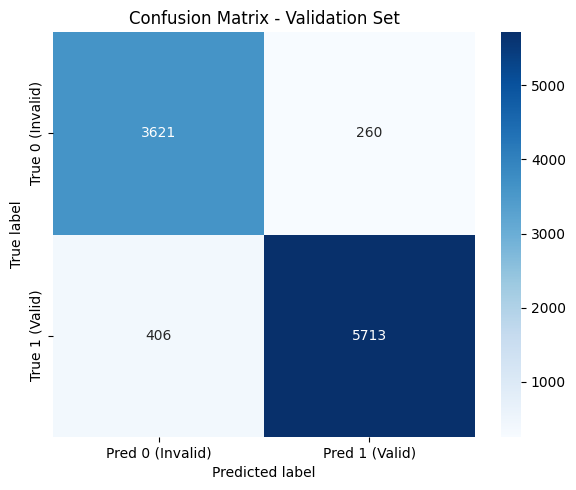

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Subset
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Evaluation on the validation set (optional: limit the number of samples to speed up)
max_eval_samples = 10000
eval_subset = Subset(val_dataset.dataset, val_dataset.indices[:max_eval_samples]) if max_eval_samples else val_dataset

pred_output = trainer.predict(eval_subset)

# For num_labels=1, we get binary logits -> sigmoid -> probability
logits = pred_output.predictions.reshape(-1)
y_prob = 1 / (1 + np.exp(-logits))
y_pred = (y_prob >= 0.5).astype(int)
y_true = pred_output.label_ids.astype(int).reshape(-1)

cm = confusion_matrix(y_true, y_pred)

print("=== Metriche Validation ===")
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
print(f"F1-score : {f1_score(y_true, y_pred, zero_division=0):.4f}")
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred 0 (Invalid)', 'Pred 1 (Valid)'],
    yticklabels=['True 0 (Invalid)', 'True 1 (Valid)']
    )
plt.title('Confusion Matrix - Validation Set')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()